In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import os

In [2]:
from src.loader import load_all_samples
from src.filter import filter_data
from src.filter import normalize_and_select_genes
from src.clustering import run_pca
from src.clustering import run_clustering

Is index unique? True
Number of mitochondrial genes detected: 13

QC metrics added to adata.obs:
['n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt']

QC Statistics:


,total_counts,n_genes_by_counts,pct_counts_mt
count,34078.000000,34078.000000,34078.000000
mean,630.604492,2290.729415,2.499186
std,61.527061,1018.252556,0.938393
min,119.023888,203.000000,0.000000
25%,592.297119,1672.000000,2.106632
50%,633.059692,2122.000000,2.416822
75%,674.417587,2642.000000,2.746958
max,802.334778,10984.000000,40.870228


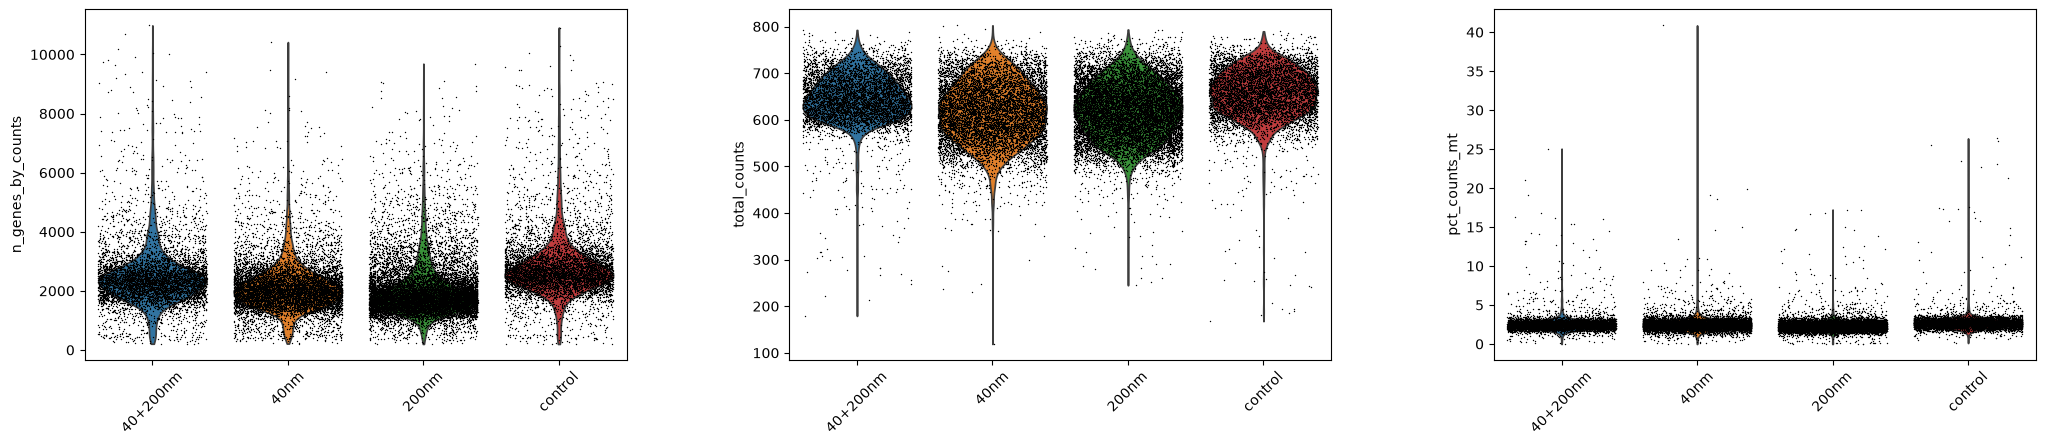

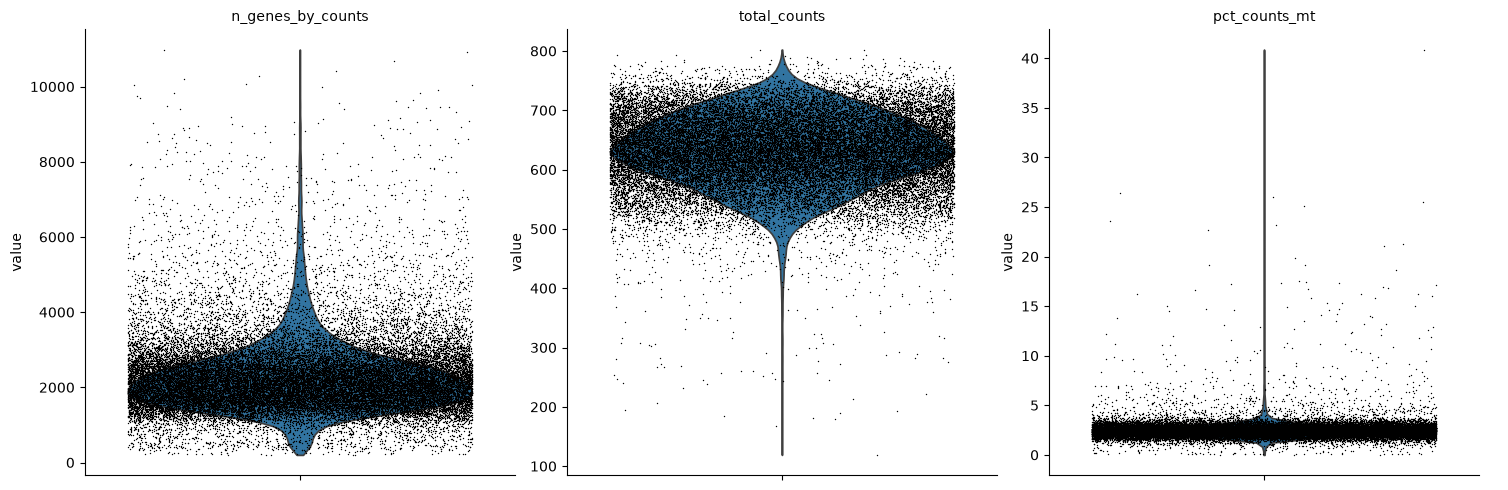

In [3]:
# Read H5AD file
adata = load_all_samples()

print(f"Is index unique? {adata.obs.index.is_unique}")

adata.var['mt'] = adata.var_names.str.startswith('MT-')

sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

print(f"Number of mitochondrial genes detected: {adata.var['mt'].sum()}")
print(f"\nQC metrics added to adata.obs:")
print([col for col in adata.obs.columns if col.startswith(('total_counts', 'n_genes', 'pct_counts'))])
# Display summary statistics
print("\nQC Statistics:")
qc_stats = adata.obs[['total_counts', 'n_genes_by_counts', 'pct_counts_mt']].describe()
display(qc_stats)

# Calculate QC metrics
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'], jitter=0.4, multi_panel=True, show=False, groupby='sample_id', rotation=45)
plt.savefig('results/qc_scatter_feature.png')

# Calculate QC metrics
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'], jitter=0.4, multi_panel=True, show=False)
plt.savefig('results/qc_scatter.png')

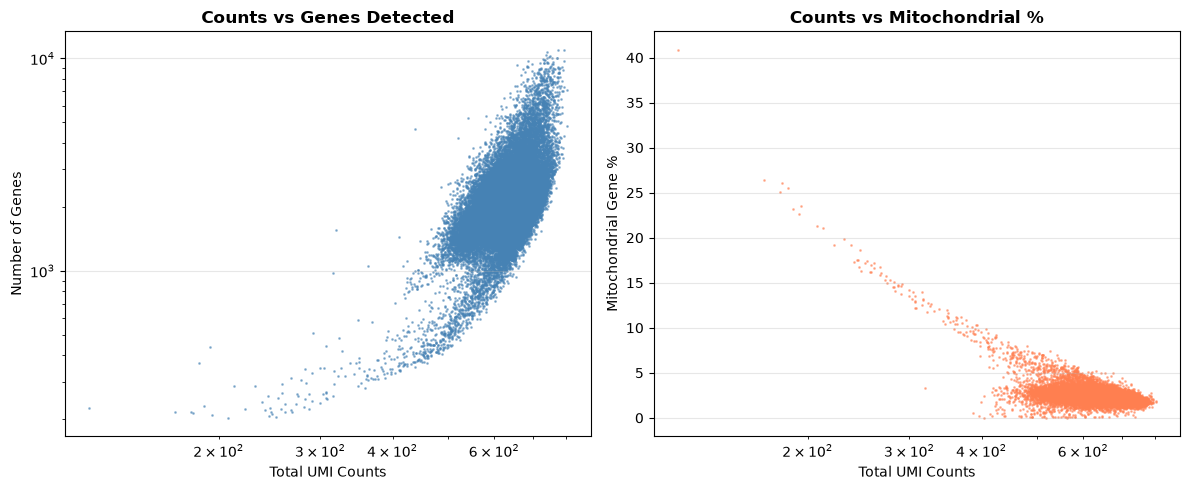


✓ QC scatter plots generated


In [4]:
# Scatter plots to identify outliers and correlations
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Total counts vs genes detected
axes[0].scatter(
    adata.obs['total_counts'],
    adata.obs['n_genes_by_counts'],
    alpha=0.5,
    s=1,
    c='steelblue'
)
axes[0].set_xlabel('Total UMI Counts', fontsize=10)
axes[0].set_ylabel('Number of Genes', fontsize=10)
axes[0].set_title('Counts vs Genes Detected', fontsize=12, fontweight='bold')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)

# Total counts vs mitochondrial percentage
axes[1].scatter(
    adata.obs['total_counts'],
    adata.obs['pct_counts_mt'],
    alpha=0.5,
    s=1,
    c='coral'
)
axes[1].set_xlabel('Total UMI Counts', fontsize=10)
axes[1].set_ylabel('Mitochondrial Gene %', fontsize=10)
axes[1].set_title('Counts vs Mitochondrial %', fontsize=12, fontweight='bold')
axes[1].set_xscale('log')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ QC scatter plots generated")

In [5]:
# Calculate how many cells each gene appears in
gene_occurrence = (adata.X > 0).sum(axis=0)
if hasattr(gene_occurrence, 'A1'): gene_occurrence = gene_occurrence.A1

import pandas as pd
# Create a frequency table for the first 10 values
counts = pd.Series(gene_occurrence).value_counts().sort_index().head(10)

print("Number of cells | Number of genes found in exactly that many cells")
print("----------------|-----------------------------------------------")
print(counts)

Number of cells | Number of genes found in exactly that many cells
----------------|-----------------------------------------------
3     754
4     321
5     171
6     290
7     261
8     195
9     203
10    180
11    159
12    160
Name: count, dtype: int64


In [6]:
adata = filter_data(adata, 500, 4000, 5)

Stats BEFORE filtering: 34078 cells, 24380 genes
Stats AFTER filtering: 31767 cells, 24380 genes


In [7]:
adata = normalize_and_select_genes(adata)

Step 1: Saving raw counts...
Step 2: Normalizing total counts...
Step 3: Log-transforming...
Step 4: Identifying Highly Variable Genes (HVGs)...
Number of HVGs after excluding MT/Ribo: 1991


/usr/lib/python3.12/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/home/jovan/Documents/gi/gi-2026/venv/lib/python3.12/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


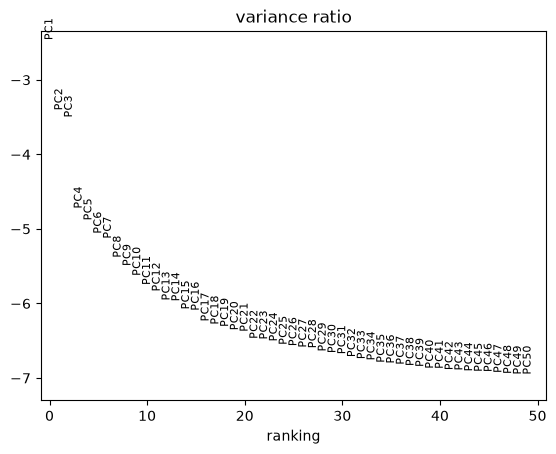

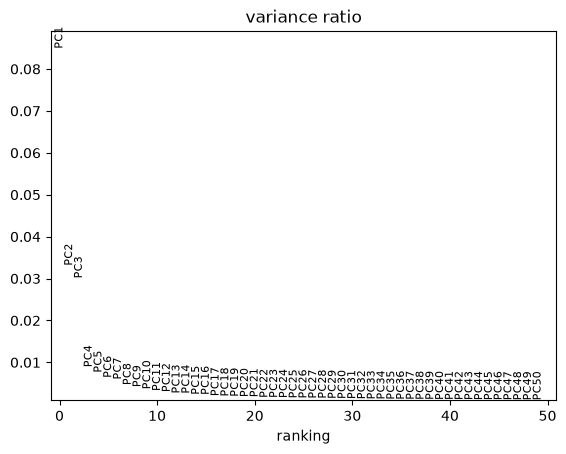

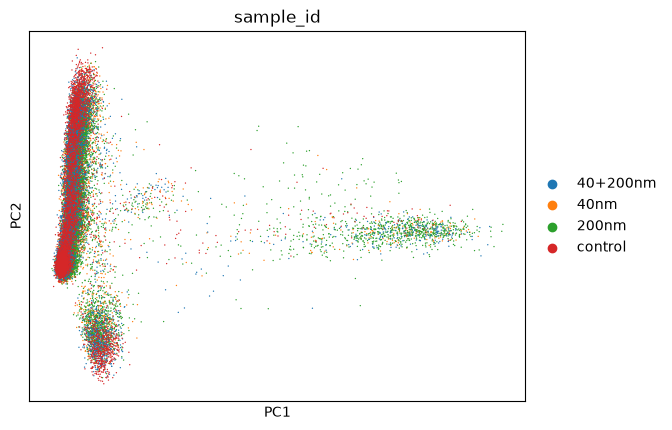

In [8]:
adata = run_pca(adata)

In [9]:
# Calculate variance explained by each PC
variance_ratio = adata.uns['pca']['variance_ratio']
print(f"\nVariance explained by first 10 PCs: {100 * variance_ratio[:10].sum():.2f}%")
print(f"Variance explained by first 30 PCs: {100 * variance_ratio[:30].sum():.2f}%")


Variance explained by first 10 PCs: 18.89%
Variance explained by first 30 PCs: 22.64%


2026-07-29 17:59:36.251371: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-29 17:59:36.432748: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-29 17:59:36.604446: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-29 17:59:36.758193: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-29 17:59:36.811542: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-29 17:59:39.709097: W tensorflow/compiler/tf2tensorrt/utils/p

/home/jovan/Documents/gi/gi-2026/src/clustering.py:46: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(


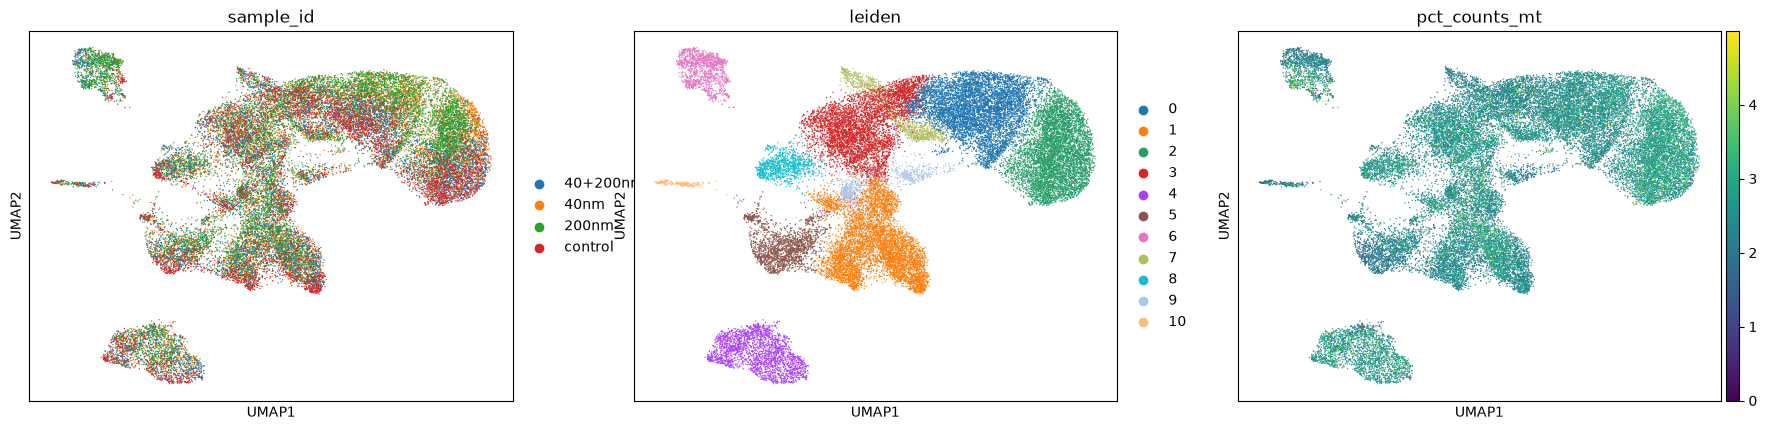

In [10]:
adata = run_clustering(adata)

n_clusters = adata.obs['leiden'].nunique()

In [11]:
# Find marker genes for Leiden clusters
sc.tl.rank_genes_groups(
    adata,
    groupby='leiden',  # Group by Leiden clusters
    method='wilcoxon',  # Statistical test method - does not assume normal distribution, compares medians rather than mean
    key_added='rank_genes_leiden',
    use_raw=False,
    layer='norm_log'
)

print("✓ Marker genes computed for Leiden clusters")
print(f"  - Method: wilcoxon")
print(f"  - Clusters analyzed: {n_clusters}")

✓ Marker genes computed for Leiden clusters
  - Method: wilcoxon
  - Clusters analyzed: 11


In [12]:
# Overview plot of top marker genes
sc.pl.rank_genes_groups(
    adata,
    n_genes=20,
    sharey=False,
    key='rank_genes_leiden',
    show=False
)

plt.savefig('results/marker_genes.png')
plt.close()

print("\n✓ Marker genes overview plot generated")


✓ Marker genes overview plot generated


In [13]:
# Extract marker genes as a DataFrame
marker_genes_df = sc.get.rank_genes_groups_df(
    adata,
    group=None,  # Get markers for all groups
    key='rank_genes_leiden'
)

print("\nTop 5 marker genes per cluster:")
print("="*80)

for cluster in sorted(adata.obs['leiden'].unique()):
    cluster_markers = marker_genes_df[
        marker_genes_df['group'] == cluster
    ].head(5)

    print(f"\nCluster {cluster}:")
    for idx, row in cluster_markers.iterrows():
        print(f"  {row['names']:15s} | score: {row['scores']:6.2f} | "
              f"logFC: {row['logfoldchanges']:6.2f} | p-val: {row['pvals']:.2e}")


Top 5 marker genes per cluster:

Cluster 0:
  EEF1B2          | score:  67.11 | logFC:   1.16 | p-val: 0.00e+00
  LTB             | score:  64.67 | logFC:   1.79 | p-val: 0.00e+00
  ANK3            | score:  60.39 | logFC:   2.18 | p-val: 0.00e+00
  CCR7            | score:  60.13 | logFC:   1.78 | p-val: 0.00e+00
  TSHZ2           | score:  59.56 | logFC:   3.23 | p-val: 0.00e+00

Cluster 1:
  CCL5            | score: 106.86 | logFC:   4.64 | p-val: 0.00e+00
  AOAH            | score:  91.16 | logFC:   3.70 | p-val: 0.00e+00
  ZEB2            | score:  84.61 | logFC:   3.51 | p-val: 0.00e+00
  TGFBR3          | score:  77.31 | logFC:   3.40 | p-val: 0.00e+00
  C1orf21         | score:  77.01 | logFC:   3.97 | p-val: 0.00e+00

Cluster 10:
  ATP10D          | score:  23.34 | logFC:   7.41 | p-val: 1.90e-120
  SIPA1L1         | score:  22.79 | logFC:   4.29 | p-val: 5.65e-115
  GAB2            | score:  22.68 | logFC:   5.09 | p-val: 6.79e-114
  CHN2            | score:  21.47 | logFC: 

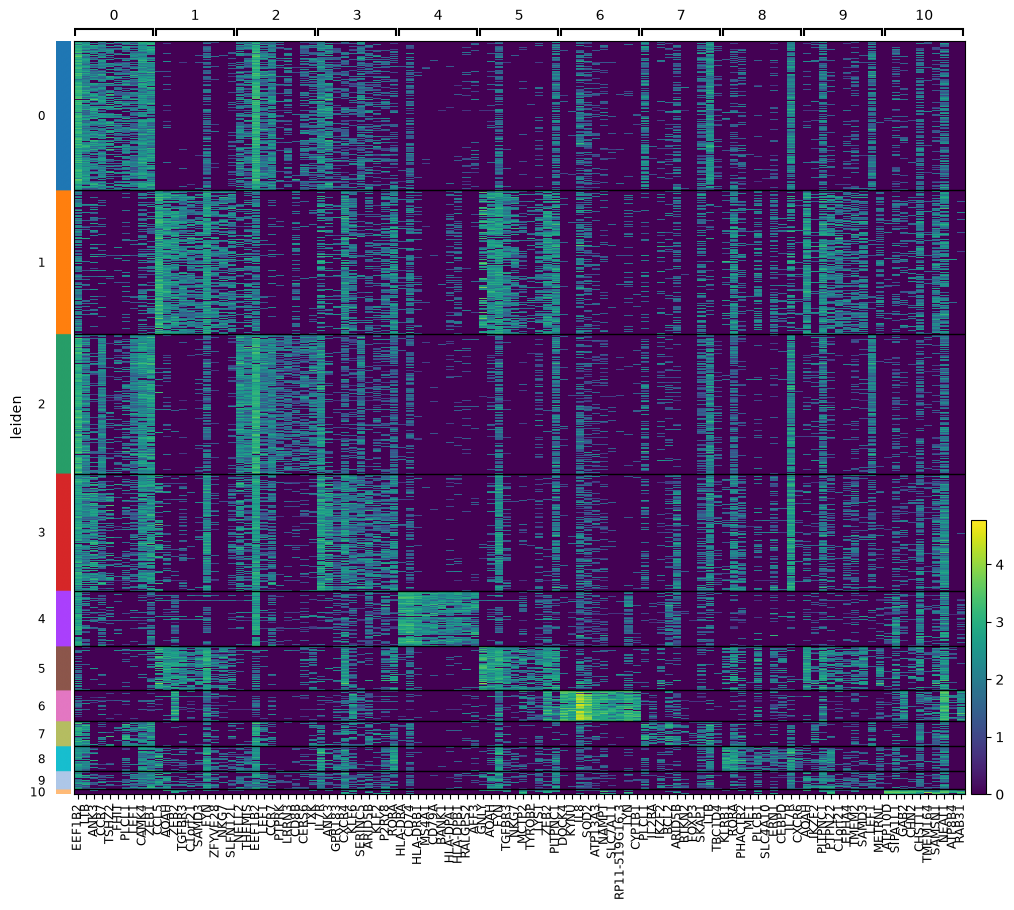


✓ Marker genes heatmap generated


In [14]:
# Heatmap of top marker genes
sc.pl.rank_genes_groups_heatmap(
    adata,
    n_genes=10,
    key='rank_genes_leiden',
    groupby='leiden',
    show_gene_labels=True,
    figsize=(12, 10),
    dendrogram=False,
    show=True
)

print("\n✓ Marker genes heatmap generated")

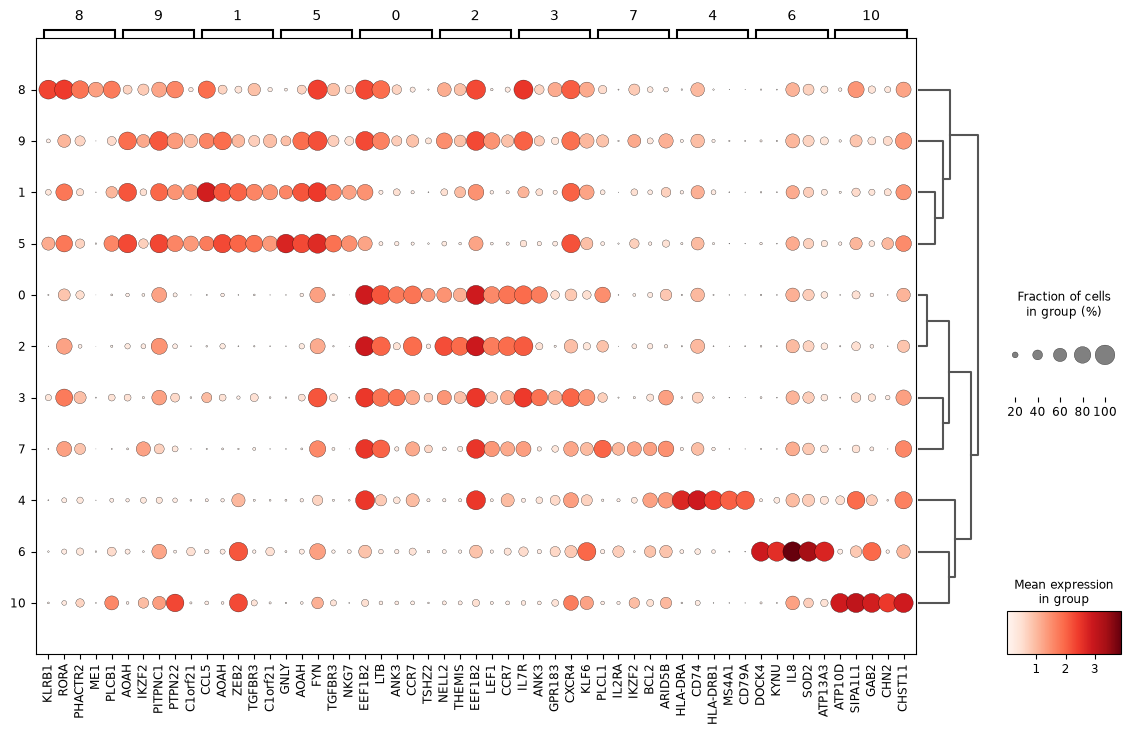


✓ Marker genes dot plot generated


In [15]:
# Dot plot of top marker genes
sc.tl.dendrogram(adata, groupby='leiden')
sc.pl.rank_genes_groups_dotplot(
    adata,
    n_genes=5,
    key='rank_genes_leiden',
    groupby='leiden',
    figsize=(14, 8),
    show=True
)

print("\n✓ Marker genes dot plot generated")

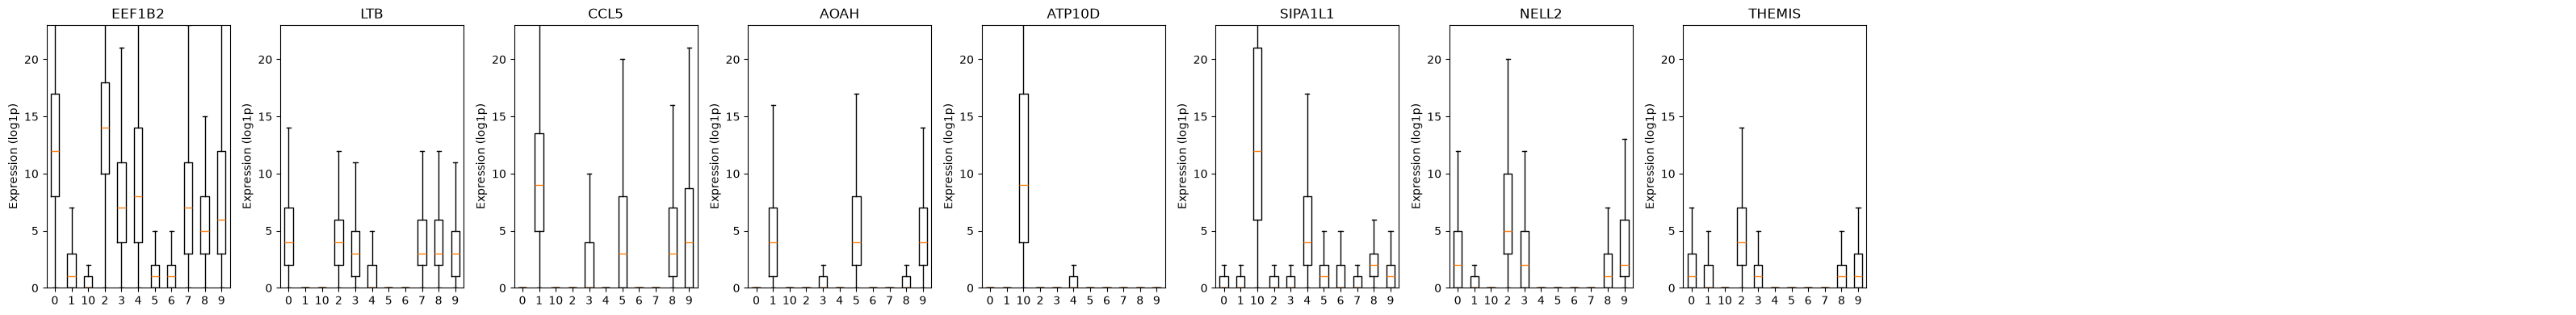


✓ Marker genes plots generated


In [32]:
# Get top 3 marker genes for all clusters for violin plots
top_genes = []
for cluster in sorted(adata.obs['leiden'].unique()):  # All clusters
    cluster_markers = marker_genes_df[
        marker_genes_df['group'] == cluster
    ].head(2)
    top_genes.extend(cluster_markers['names'].tolist())

# Remove duplicates while preserving order
top_genes = list(dict.fromkeys(top_genes))[:8]  # Limit to 8 genes

# Violin plot
if len(top_genes) > 0:
    genes = top_genes
    clusters = sorted(adata.obs['leiden'].unique())

    # Choose expression source:
    # - adata.X        → usually log1p-normalized
    # - adata.layers[normlog]    → if log1p stored
    # - adata.layers[] → e.g. 'counts'
    gene_idx = [adata.var_names.get_loc(g) for g in genes]
    X = adata.layers["counts"][:, gene_idx]

    # Convert sparse to dense if needed
    if hasattr(X, "toarray"):
        X = X.toarray()

    # Build expression DataFrame
    expr = pd.DataFrame(
        X,
        columns=genes,
        index=adata.obs['leiden']
    )

    # -----------------------------
    # Plot: boxplots in a grid
    # -----------------------------
    n_genes = len(genes)
    n_cols = len(adata.obs['leiden'].unique())
    n_rows = int(np.ceil(n_genes / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(32, 4* n_rows))
    axes = axes.flatten()

    # Optional: consistent y-axis across genes
    ymax = np.percentile(expr.values, 99)

    for ax, gene in zip(axes, genes):
        data = [expr.loc[cluster, gene].values for cluster in clusters]

        ax.boxplot(
            data,
            showfliers=False
        )
        ax.set_title(gene)
        ax.set_xticks(range(1, len(clusters) + 1))
        ax.set_xticklabels(clusters, rotation=0)
        ax.set_ylabel("Expression (log1p)")
        ax.set_ylim(0, ymax)

    # Hide unused panels
    for ax in axes[len(genes):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()
    print("\n✓ Marker genes plots generated")
else:
    print("\n⚠ No marker genes found for violin plot")

In [17]:
from panhumanpy import AzimuthNN

azimuth = AzimuthNN(adata)

I0000 00:00:1785340877.820476   14794 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-07-29 18:01:17.827814: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2343] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
/home/jovan/Documents/gi/gi-2026/venv/lib/python3.12/site-packages/panhumanpy/ANNotate.py:1402: UserWarning: Ensure that the features metadata is indexed with gene names.
  warnings.warn(


Integer counts detected by panhumanpy.ANNotate : False
Log-normalization performed by panhumanpy.ANNotate: False


/home/jovan/Documents/gi/gi-2026/venv/lib/python3.12/site-packages/panhumanpy/ANNotate_tools.py:2817: UserWarning: Low feature overlap (19.2%) may lead to suboptimal results.
  warnings.warn(


Query object:
    Total number of cells: 31767
    Total number of features: 1991
    Overlap w. feature reference: 971 (~19%)

Splitting query data into 4 evaluation batch(es) of up to 
8192 cells.

Interpreting label predictions for consistent granularity at broad, medium, fine level(s).

Running model:


I0000 00:00:1785340882.845865   15004 service.cc:146] XLA service 0x78e6ac0109d0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1785340882.845921   15004 service.cc:154]   StreamExecutor device (0): Host, Default Version
2026-07-29 18:01:22.921285: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


  4/256 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step

I0000 00:00:1785340883.632233   15004 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


256/256 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step
256/256 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step
256/256 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step


In [18]:
predictions = azimuth.cells_meta
adata.obs['azimuth_type'] = predictions['azimuth_broad'] # Broad categories
adata.obs['azimuth_fine'] = predictions['azimuth_fine']   # Specific subsets

embeddings = azimuth.azimuth_embed()

# 3. Add the Azimuth UMAP coordinates to your object
# This allows you to show your cells in the "Reference Space"
adata.obsm['X_azimuth_umap'] = azimuth.azimuth_umap()

print("✓ Azimuth annotation complete.")

Extracting azimuth embeddings:
256/256 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step
256/256 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step
256/256 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step


/home/jovan/Documents/gi/gi-2026/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP(angular_rp_forest=True, metric='cosine', min_dist=0.3, n_jobs=1, n_neighbors=30, random_state=42, verbose=True)
Wed Jul 29 18:03:14 2026 Construct fuzzy simplicial set
Wed Jul 29 18:03:14 2026 Finding Nearest Neighbors
Wed Jul 29 18:03:14 2026 Building RP forest with 14 trees
Wed Jul 29 18:03:21 2026 NN descent for 15 iterations
	 1  /  15
	 2  /  15
	 3  /  15
	Stopping threshold met -- exiting after 3 iterations
Wed Jul 29 18:03:43 2026 Finished Nearest Neighbor Search
Wed Jul 29 18:03:45 2026 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Wed Jul 29 18:04:21 2026 Finished embedding
✓ Azimuth annotation complete.


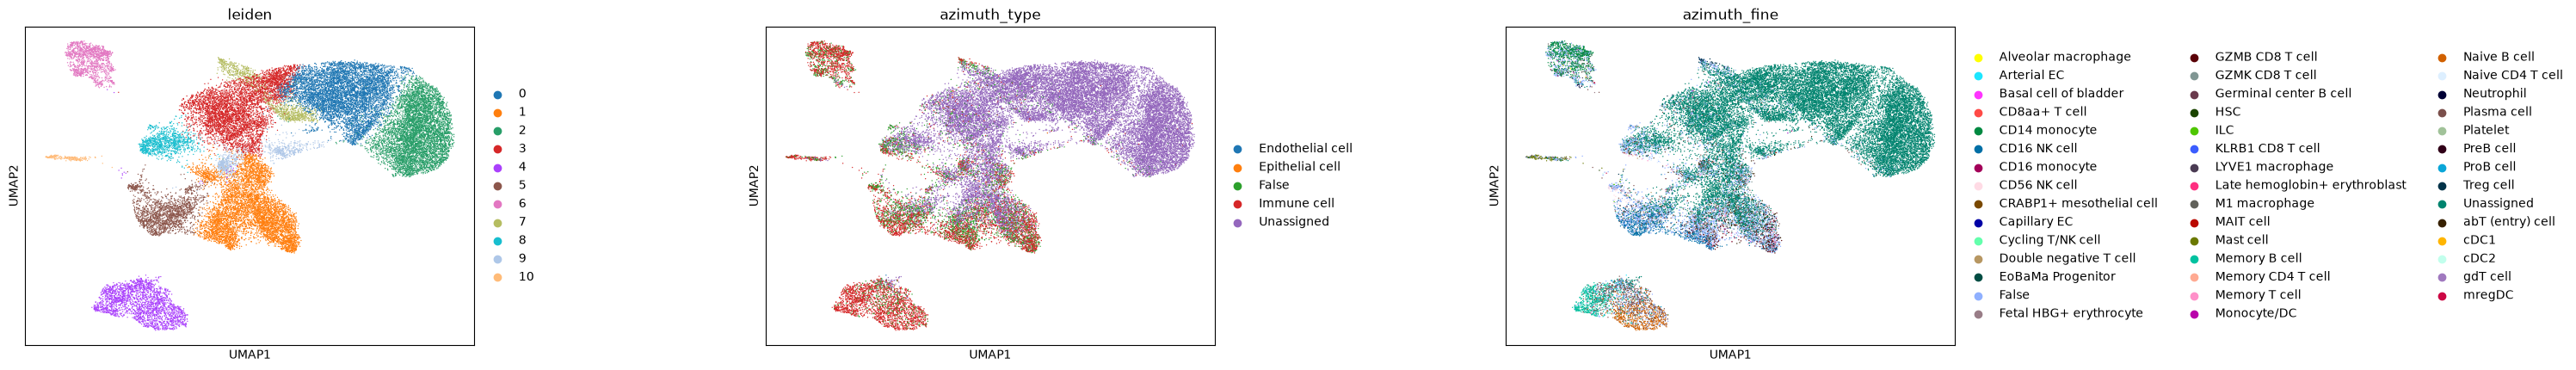

In [ ]:
sc.pl.umap(adata, color=['leiden', 'azimuth_type', 'azimuth_fine'], wspace=0.5, show=False)
plt.savefig('results/leiden_azimuth.png')
plt.close()

In [40]:
sc.pl.embedding(adata, basis='azimuth_umap', color='azimuth_fine', title='Azimuth Reference Projection', show=False)
plt.savefig('results/azimuth_umap.png')
plt.close()

In [21]:
print(adata.var_names[:10])

Index(['7SK.2', 'A2M', 'AARD', 'ABAT', 'ABCA1', 'ABCA12', 'ABCA13', 'ABCB1',
       'ABCB5', 'ABHD17C'],
      dtype='object')


In [23]:
import pandas as pd

# Create a cross-tabulation of your Leiden clusters vs Azimuth labels
comparison = pd.crosstab(adata.obs['leiden'], adata.obs['azimuth_type'], margins=True)
print(comparison)

azimuth_type  Endothelial cell  Epithelial cell  False  Immune cell  \
leiden                                                                
0                            0                1     61           20   
1                            0                2   1574         1897   
2                            0                0     43           31   
3                            0                3    228          122   
4                            1                0    372         1859   
5                            0                0    659          830   
6                            1                2    359          919   
7                            0                0    123           63   
8                            0                0    293          146   
9                            0                0    113          124   
10                           0                0     44          142   
All                          2                8   3869         6153   

azimu

In [35]:
# from https://azimuth.hubmapconsortium.org/references/

azimuth_markers = {
    "Mono": ["CTSS", "FCN1", "NEAT1", "LYZ", "PSAP", "S100A9", "AIF1", "MNDA", "SERPINA1", "TYROBP"],
    "CD4 T": ["IL7R", "MAL", "LTB", "CD4", "LDHB", "TPT1", "TRAC", "TMSB10", "CD3D", "CD3G"],
    "CD8 T": ["CD8B", "CD8A", "CD3D", "TMSB10", "HCST", "CD3G", "LINC02446", "CTSW", "CD3E", "TRAC"],
    "NK": ["NKG7", "KLRD1", "TYROBP", "GNLY", "FCER1G", "PRF1", "CD247", "KLRF1", "CST7", "GZMB"],
    "B": ["CD79A", "RALGPS2", "CD79B", "MS4A1", "BANK1", "CD74", "TNFRSF13C", "HLA-DQA1", "IGHM", "MEF2C"],
    "other T": ["CD3D", "TRDC", "GZMK", "KLRB1", "NKG7", "TRGC2", "CST7", "LYAR", "KLRG1", "GZMA"],
    "DC": ["CD74", "HLA-DPA1", "HLA-DPB1", "HLA-DQA1", "CCDC88A", "HLA-DRA", "HLA-DMA", "CST3", "HLA-DQB1", "HLA-DRB1"]
}

In [36]:
for cell_type, genes in azimuth_markers.items():
    # Filter the list to only genes that exist in your adata (to avoid errors)
    valid_genes = [g for g in genes if g in adata.var_names]
    
    # Run the scoring
    sc.tl.score_genes(adata, gene_list=valid_genes, score_name=f'score_{cell_type}')

print("✓ All Azimuth scores calculated.")

✓ All Azimuth scores calculated.


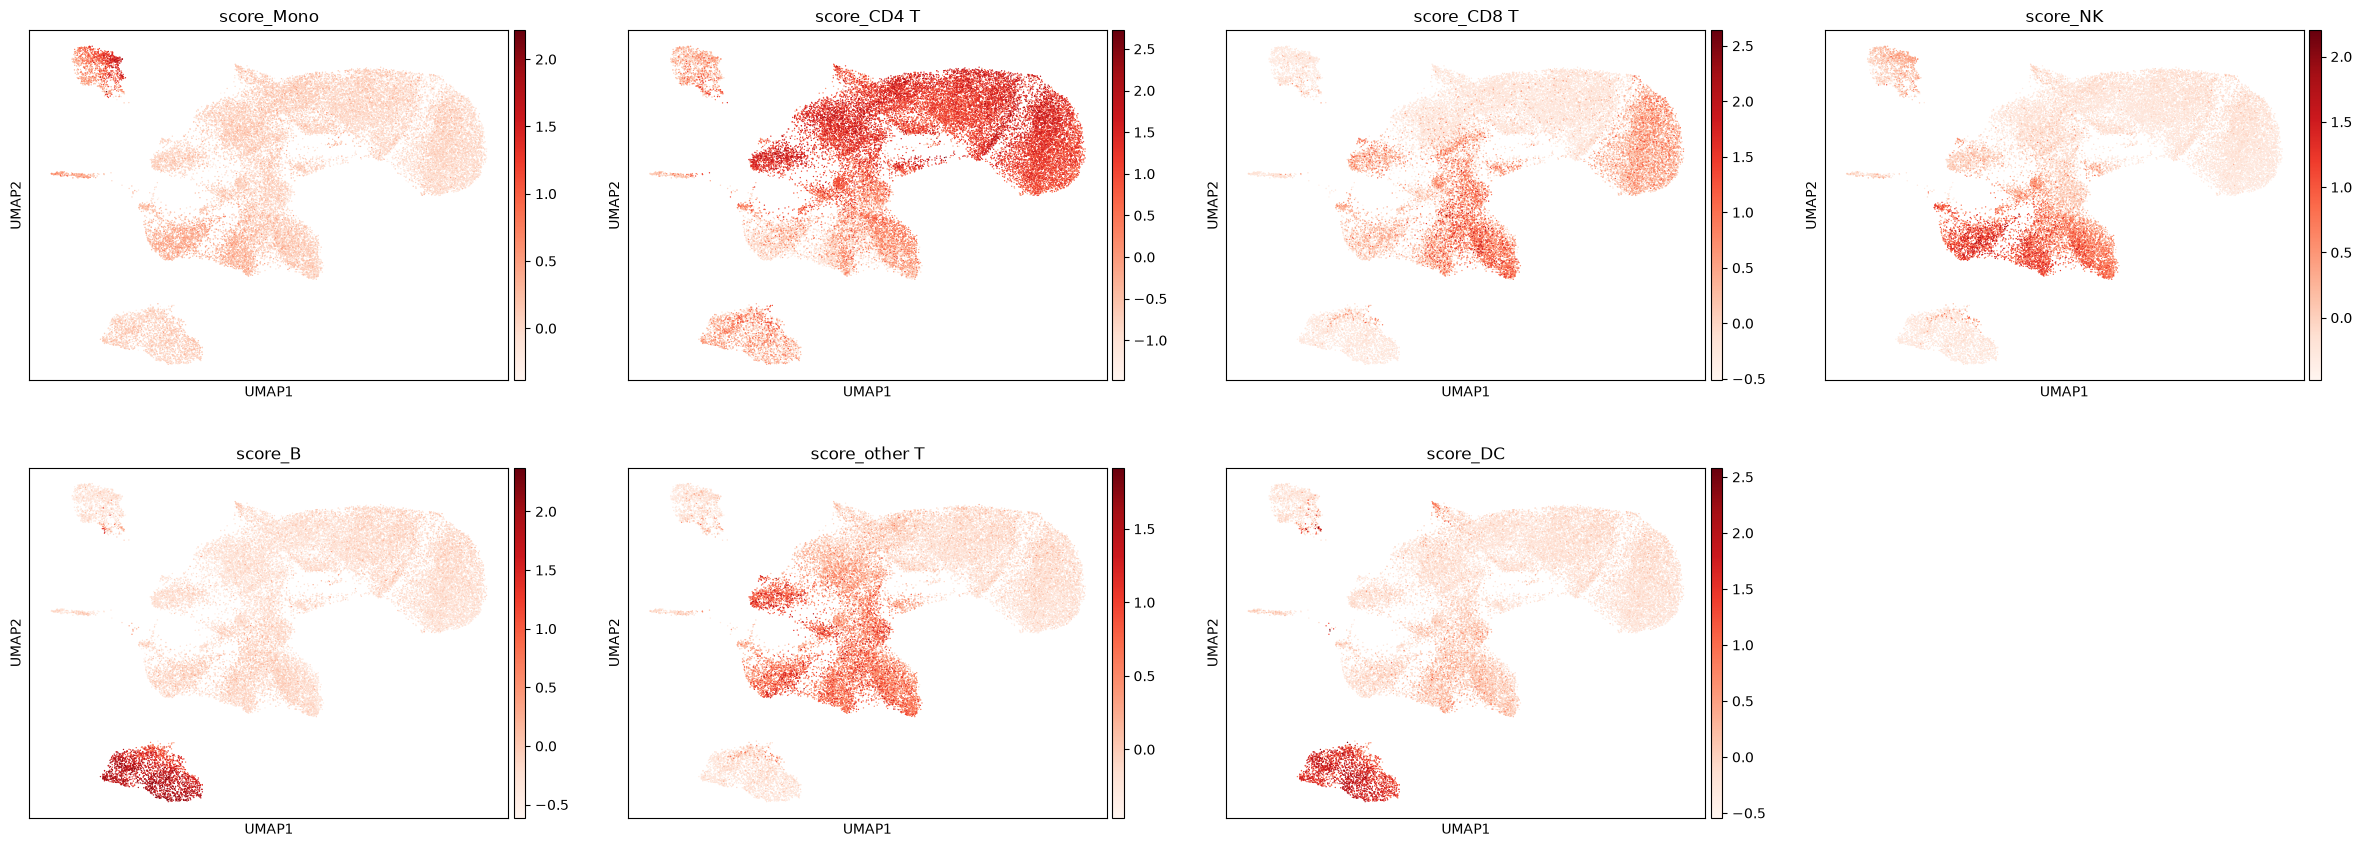

In [39]:
# Look at B-cells and Monocytes
sc.pl.umap(adata, color=[f'score_{cell_type}' for cell_type in azimuth_markers.keys()], cmap='Reds')

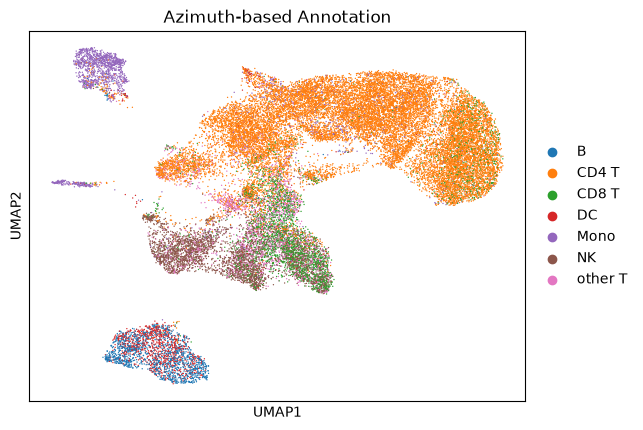

In [ ]:
# List of the score columns we just created
score_columns = [f'score_{ct}' for ct in azimuth_markers.keys()]

# For every cell, find which score is the highest
adata.obs['predicted_type'] = adata.obs[score_columns].idxmax(axis=1)

# Clean up the names (remove 'score_')
adata.obs['predicted_type'] = adata.obs['predicted_type'].str.replace('score_', '')

# Plot the final result
sc.pl.umap(adata, color='predicted_type', title='Azimuth-based Annotation', show=False)
